# I-24 static calibration: FD screen and VSL mechanism

1. **Data screen:** does the data show a capacity drop (Diagnostic 1), and is the calibrated static FD consistent with the observed flows (Diagnostic 2)?
2. **VSL mechanism:** where and how `optimal_vsl.npy` reduces TTS in the static-calibration METANET model.

There is no fixed bottleneck head on this corridor, so nothing here looks for one. Capacity and discharge are measured per cell by traffic state instead: the *free-flow branch* is intervals at or above `V_FREE_FLOW`, the *congested branch* is intervals below `V_CONGESTED`.

All flows and densities are per lane. The static FD is $Q_e(\rho)=\rho\,v_f\,e^{-(\rho/\rho_c)^a/a}$, so $Q_{cap}=v_f\rho_c e^{-1/a}$.

In [1]:
import sys, os
_root = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(_root, "src", "paths.py")):
    _parent = os.path.dirname(_root)
    if _parent == _root:
        raise RuntimeError("Could not find src/paths.py above the working directory")
    _root = _parent
sys.path.insert(0, os.path.join(_root, "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from paths import i24_data, i24_results
from cc_analysis import load_day_data, ff_tts_vkm, L, time_step
from traffic_sim import run_metanet_sim, calculate_V_arr
from optimization_utils import CALIB_PARAM_BOUNDS

DATE = "11_30"
AGG_STEPS = 1          # 1-min aggregation for the data screen
V_CONGESTED = 40       # km/h, "in queue"
V_FREE_FLOW = 70       # km/h, free-flow branch (100 leaves almost no samples on 11/30)
NO_LIMIT = 1e4         # speed limit value that never binds

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/var/folders/kl/txwf6c7d73v3xczbyqm3trhw0000gn/T/ipykernel_33986/1592137353.py:11: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Load data, calibration, and simulate

In [2]:
day = load_day_data(DATE)
P = day["static_params"]
n_seg = day["num_segments"]
lanes = np.array([day["lane_dict"][i] for i in range(n_seg)], dtype=float)
vsl = np.load(i24_results(DATE, "optimal_vsl.npy"))
T_min = np.arange(vsl.shape[0]) * time_step * 60

def simulate(speeds, real_data=False, until_ff=False):
    rho, v, queue, fo, _, tts = run_metanet_sim(
        time_step, L, day["init_state"], day["data_inflow"], day["ds_density_norm"], P,
        lanes=day["lane_dict"], vsl_speeds=speeds, opt=True, real_data=real_data,
        until_ff=until_ff)
    return dict(rho=rho[:-1], v=v[:-1], queue=queue[:-1, 0], inflow=fo[:-1, 0], tts=tts,
                N=(rho * lanes * L).sum(axis=1))

nc = simulate(None)
ctl = simulate(vsl)
nc_paper = simulate(None, real_data=True)   # baseline convention used in cc_analysis
print(f"TTS no control: {nc['tts']:.1f} veh-h (paper baseline: {nc_paper['tts']:.1f}), "
      f"VSL: {ctl['tts']:.1f} veh-h  ->  saved {nc['tts'] - ctl['tts']:.1f} ({1 - ctl['tts'] / nc['tts']:.0%})")
print(f"Max origin queue: no control {nc['queue'].max():.1f} veh, VSL {ctl['queue'].max():.1f} veh")

# Observed data, all 16 columns (0 = upstream BC, 15 = downstream BC), per lane
col_lanes = np.r_[np.load(i24_data(DATE, "lane_mapping.npy"))[0], lanes, np.load(i24_data(DATE, "lane_mapping.npy"))[-1]]
q_obs = np.maximum(np.load(i24_data(DATE, "q_hat.npy")), 1e-3) / col_lanes
rho_obs = np.maximum(np.load(i24_data(DATE, "rho_hat.npy")), 1e-3) / col_lanes
labels = ["up BC"] + [f"S{i}" for i in range(n_seg)] + ["down BC"]
Q_cap = np.r_[np.nan, P["v_free"] * P["p_crit"] * np.exp(-1 / P["a"]), np.nan]

def block_mean(x, k):
    n = x.shape[0] // k
    return x[: n * k].reshape(n, k, *x.shape[1:]).mean(axis=1)
q_agg, rho_agg = block_mean(q_obs, AGG_STEPS), block_mean(rho_obs, AGG_STEPS)
v_agg = q_agg / rho_agg

TTS no control: 550.6 veh-h (paper baseline: 550.6), VSL: 383.5 veh-h  ->  saved 167.1 (30%)
Max origin queue: no control 0.0 veh, VSL 0.0 veh


## 1. Data screen

Observed speed, the model with and without control, and the speed limit shown only where it binds, i.e. where $v_{ctrl} < V_e(\rho)$.

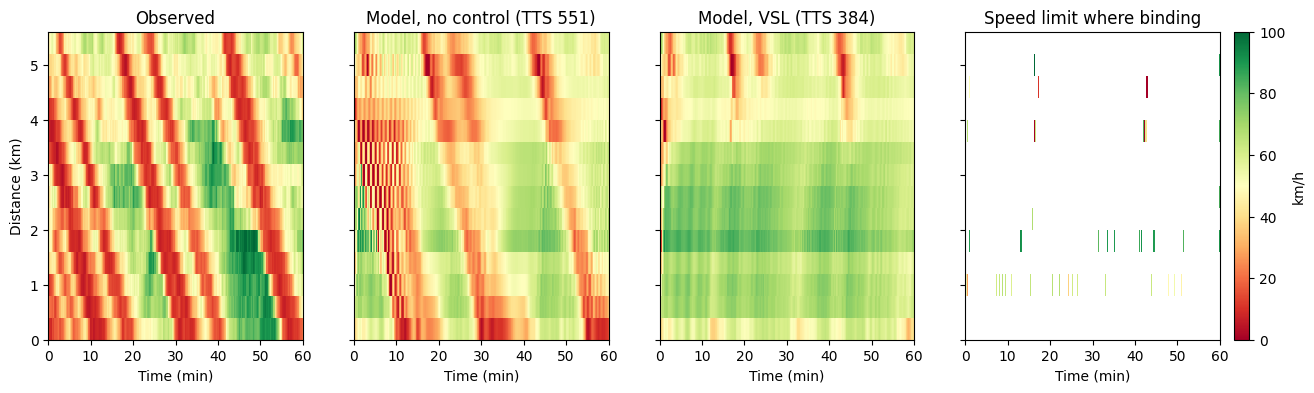

In [3]:
V_e_ctl = calculate_V_arr(ctl["rho"], np.full_like(vsl, NO_LIMIT), P["a"], P["p_crit"], P["v_free"])
binding = vsl < V_e_ctl - 1

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
kw = dict(origin="lower", aspect="auto", cmap="RdYlGn", vmin=0, vmax=100, interpolation="none")
axes[0].imshow((q_obs / rho_obs).T, extent=[0, 60, -L, (n_seg + 1) * L], **kw)
axes[1].imshow(nc["v"].T, extent=[0, 60, 0, n_seg * L], **kw)
im = axes[2].imshow(ctl["v"].T, extent=[0, 60, 0, n_seg * L], **kw)
axes[3].imshow(np.where(binding, vsl, np.nan).T, extent=[0, 60, 0, n_seg * L], **kw)
for ax, t in zip(axes, ["Observed", f"Model, no control (TTS {nc['tts']:.0f})",
                        f"Model, VSL (TTS {ctl['tts']:.0f})", "Speed limit where binding"]):
    ax.set_title(t); ax.set_xlabel("Time (min)")
axes[0].set_ylabel("Distance (km)")
fig.colorbar(im, ax=axes, label="km/h", pad=0.01)
plt.show()

**Diagnostic 1 (is there a drop?):** observed per-lane (ρ, q) colored by speed, against the calibrated static FD (black) and $Q_{cap}$ (dashed). Green is the free-flow branch capacity $\hat Q_{ff}$ (95th percentile of flow at or above `V_FREE_FLOW`); purple is the congested branch's best flow $\hat Q_{cong}$ (95th percentile below `V_CONGESTED`).

The second grid repeats this with the **calibrated model's own states** from the no-control run, on the same axes. The FD curve is the same; only the scatter changes. Where the model's cloud sits off its own curve, the equilibrium relation is not what is carrying the dynamics there — the convection, anticipation and ramp terms are.

**Diagnostic 2 (is the calibrated FD usable?):** the bar chart compares the two empirical numbers with the calibrated $Q_{cap}$ per cell. Where observed flow runs above $Q_{cap}$, the static FD cannot carry what was measured and its capacity is not a physical one.

free-flow intervals per cell (threshold 70 km/h): [ 70  59  84  80  76  64  30  89  74  62  72  14   1   0   5 156]
congested intervals per cell (threshold 40 km/h): [214 212 209 189 174 159 190 137 138 136 152 161 151 126  97  57]


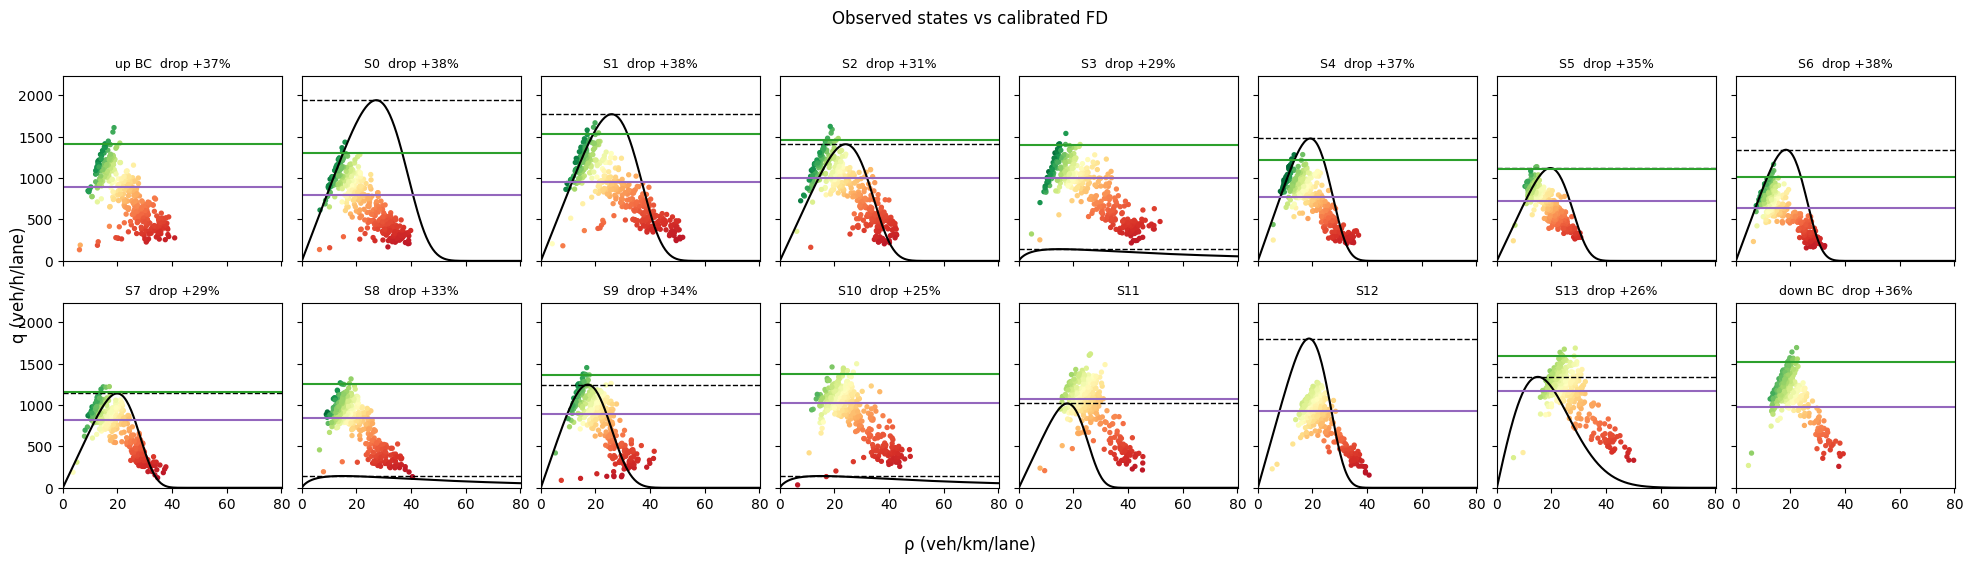

In [4]:
def branch_q(mask, c):
    return np.percentile(q_agg[mask[:, c], c], 95) if mask[:, c].sum() >= 3 else np.nan

is_ff, is_cong = v_agg >= V_FREE_FLOW, v_agg < V_CONGESTED
Q_ff = np.array([branch_q(is_ff, c) for c in range(n_seg + 2)])
Q_cong = np.array([branch_q(is_cong, c) for c in range(n_seg + 2)])
drop = 1 - Q_cong / Q_ff
print(f"free-flow intervals per cell (threshold {V_FREE_FLOW} km/h): {is_ff.sum(axis=0)}")
print(f"congested intervals per cell (threshold {V_CONGESTED} km/h): {is_cong.sum(axis=0)}")

# Model states from the no-control run, per lane. Shared axis limits so the two grids compare.
rho_mod, v_mod = nc["rho"], nc["v"]
q_mod = rho_mod * v_mod
FD_XLIM = (0, max(rho_agg.max(), rho_mod.max()) * 1.05)
FD_YLIM = (0, max(q_agg.max(), q_mod.max()) * 1.05)
rg = np.linspace(0, FD_XLIM[1], 200)

def fd_curve(ax, i):
    ax.plot(rg, rg * P["v_free"][i] * np.exp(-(rg / P["p_crit"][i]) ** P["a"][i] / P["a"][i]), "k-")
    ax.axhline(Q_cap[i + 1], color="k", ls="--", lw=1)

fig, axes = plt.subplots(2, 8, figsize=(20, 5.5), sharex=True, sharey=True)
for c, ax in enumerate(axes.flat):
    ax.scatter(rho_agg[:, c], q_agg[:, c], c=v_agg[:, c], cmap="RdYlGn", vmin=0, vmax=100, s=8)
    if 1 <= c <= n_seg:
        fd_curve(ax, c - 1)
    if np.isfinite(Q_ff[c]):
        ax.axhline(Q_ff[c], color="tab:green")
    if np.isfinite(Q_cong[c]):
        ax.axhline(Q_cong[c], color="tab:purple")
    ax.set_title(f"{labels[c]}" + (f"  drop {drop[c]:+.0%}" if np.isfinite(drop[c]) else ""), fontsize=9)
ax.set_xlim(*FD_XLIM); ax.set_ylim(*FD_YLIM)
fig.suptitle("Observed states vs calibrated FD", y=1.0)
fig.supxlabel("ρ (veh/km/lane)"); fig.supylabel("q (veh/h/lane)")
plt.tight_layout(); plt.show()

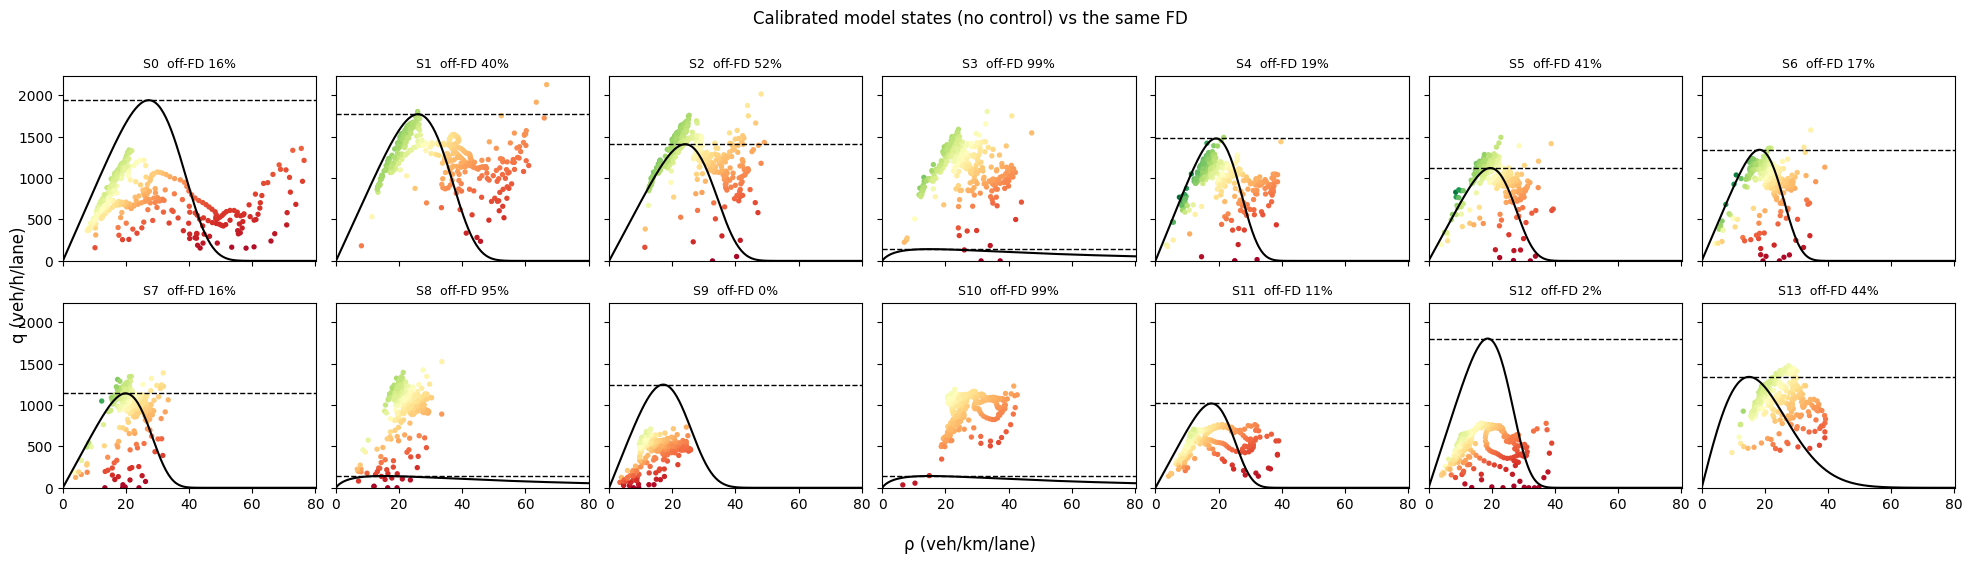

In [5]:
V_e_mod = calculate_V_arr(rho_mod, np.full_like(vsl, NO_LIMIT), P["a"], P["p_crit"], P["v_free"])
off_fd = (v_mod > V_e_mod + 5).mean(axis=0)     # share of steps the model sits above its own FD

fig, axes = plt.subplots(2, 7, figsize=(20, 5.5), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    ax.scatter(rho_mod[:, i], q_mod[:, i], c=v_mod[:, i], cmap="RdYlGn", vmin=0, vmax=100, s=8)
    fd_curve(ax, i)
    ax.set_title(f"S{i}  off-FD {off_fd[i]:.0%}", fontsize=9)
ax.set_xlim(*FD_XLIM); ax.set_ylim(*FD_YLIM)
fig.suptitle("Calibrated model states (no control) vs the same FD", y=1.0)
fig.supxlabel("ρ (veh/km/lane)"); fig.supylabel("q (veh/h/lane)")
plt.tight_layout(); plt.show()

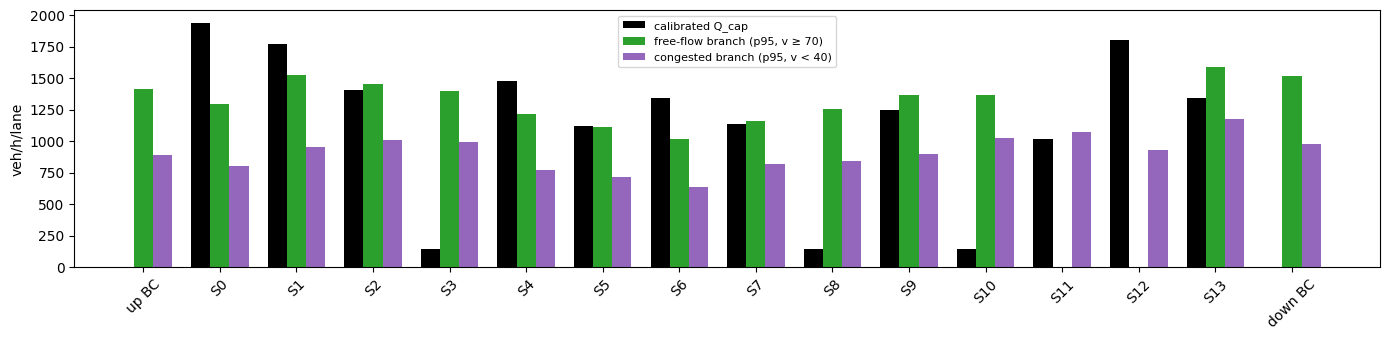

In [6]:
x = np.arange(n_seg + 2)
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(x - 0.25, Q_cap, 0.25, color="k", label="calibrated Q_cap")
ax.bar(x, Q_ff, 0.25, color="tab:green", label=f"free-flow branch (p95, v ≥ {V_FREE_FLOW})")
ax.bar(x + 0.25, Q_cong, 0.25, color="tab:purple", label=f"congested branch (p95, v < {V_CONGESTED})")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
ax.set(ylabel="veh/h/lane"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

How does the VSL reduce TTS?

Both runs admit the same exogenous inflow (the origin queue stays empty), so $\Delta TTS = T\sum_t \Delta N(t)$. Here $N$ is the number of vehicles in the corridor, and any change in $N$ must leave through an exit. Left: vehicles removed from the corridor over time. Right: cumulative extra exits by location, split into the mainline end and each off-ramp ($q_i\,\beta_i/(1-\beta_i)$).

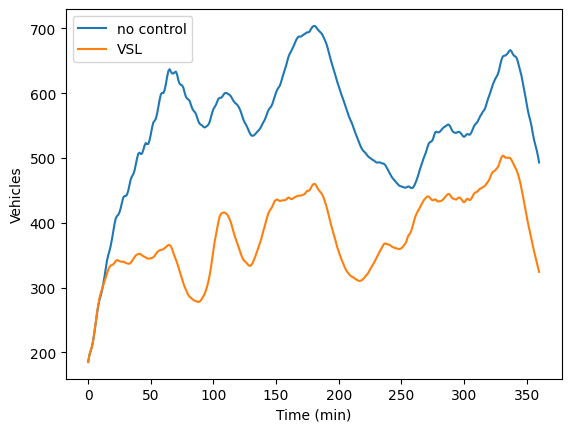

In [7]:
plt.plot(nc["N"], label="no control")
plt.plot(ctl["N"], label="VSL")
plt.xlabel("Time (min)")
plt.ylabel("Vehicles")
plt.legend()
plt.show()

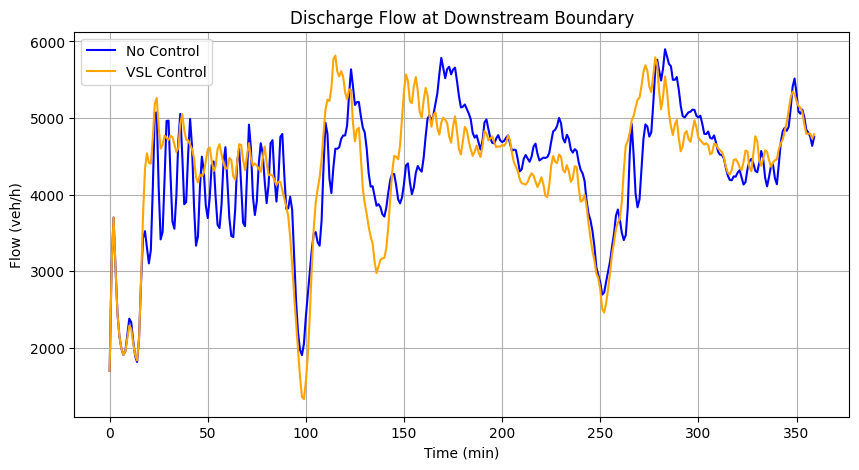

In [8]:
# Plotting the discharge flow at the downstream boundary for both scenarios
nc_outflow = nc['rho'][:, -1] * nc['v'][:, -1] * lanes[-1]
ctl_outflow = ctl['rho'][:, -1] * ctl['v'][:, -1] * lanes[-1]
plt.figure(figsize=(10, 5))
plt.plot(nc_outflow, label="No Control", color='blue')
plt.plot(ctl_outflow, label="VSL Control", color='orange')
plt.title("Discharge Flow at Downstream Boundary")
plt.xlabel("Time (min)")
plt.ylabel("Flow (veh/h)")
plt.legend()
plt.grid()

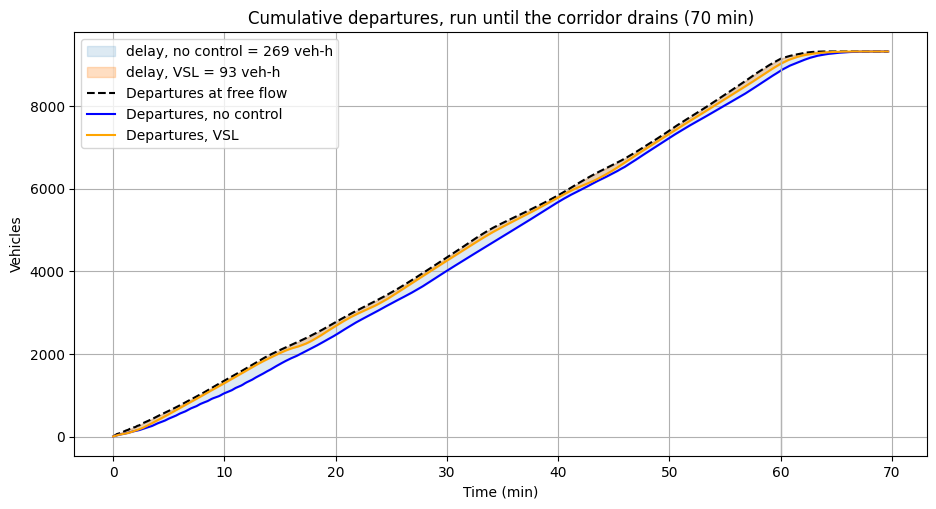

drain time: no control 69.8 min, VSL 68.2 min
vehicles served: 9324 arrivals, 9324 / 9324 departures
free-flow TTS: 298.5 veh-h from the curves, 298.9 from ff_tts_vkm
delay: no control 269.3, VSL 93.2 veh-h  ->  CC = 65.4%


In [9]:
# Cumulative departures. A vehicle departs either out of the last segment, or at an
# off-ramp: density_dynamics removes outflow/(1-beta), so the ramp takes q_i*beta_i/(1-beta_i).
# Both runs use until_ff, so every vehicle finishes its trip and the two serve the same
# vehicle-km; the time axis runs to whichever run takes longer to drain.
def total_exits(run):
    q = run["rho"] * run["v"] * lanes                      # per-segment outflow, veh/h
    return q[:, -1] + (q * P["beta"] / (1 - P["beta"])).sum(axis=1)

nc_ff, ctl_ff = simulate(None, until_ff=True), simulate(vsl, until_ff=True)
n_steps = max(nc_ff["rho"].shape[0], ctl_ff["rho"].shape[0])
t_grid = np.arange(n_steps) * time_step                    # hours
t_grid_min = t_grid * 60

def cum_departures(run):
    """Cumulative departures, held flat after that run has drained."""
    c = np.cumsum(total_exits(run)) * time_step
    out = np.full(n_steps, c[-1])
    out[: len(c)] = c
    return out

def free_flow_departures():
    """Cumulative departures if every vehicle ran at v_free, same arrivals and splits.

    Each arrival stream (mainline demand, each on-ramp, and the vehicles already in the
    corridor at t=0) is spread over its free-flow exit times. METANET removes ramp traffic
    as a sink on a segment's own outflow, so those vehicles cover no distance in the
    segment they leave at: split first, then charge the traversal time.
    """
    tau = L / P["v_free"]                                  # free-flow traversal, hours
    n_dem = day["data_inflow"].shape[0]
    D = np.zeros(n_steps)
    A = np.zeros(n_steps)

    def on_grid(per_step_veh):
        c = np.cumsum(per_step_veh)
        out = np.full(n_steps, c[-1])
        out[: len(c)] = c
        return out

    def add_stream(cum_arrivals, enter_seg, head_start=0.0):
        nonlocal D, A
        A = A + cum_arrivals
        surv, elapsed = 1.0, head_start
        for j in range(enter_seg, n_seg):
            if P["beta"][j] > 0:
                D = D + surv * P["beta"][j] * np.interp(t_grid - elapsed, t_grid, cum_arrivals, left=0.0)
            surv *= 1 - P["beta"][j]
            elapsed += tau[j]
        D = D + surv * np.interp(t_grid - elapsed, t_grid, cum_arrivals, left=0.0)

    add_stream(on_grid(day["data_inflow"] * time_step), 0)
    n0 = day["init_state"][0] * lanes * L                  # vehicles already in each segment
    for i in range(n_seg):
        if P["r"][i] > 1e-6:
            add_stream(on_grid(np.full(n_dem, P["r"][i] * time_step)), i)
        if n0[i] > 1e-9:                                   # released from mid-segment
            add_stream(on_grid(np.r_[n0[i], np.zeros(n_dem - 1)]), i, head_start=-0.5 * tau[i])
    return A, D

arrivals, ff_departures = free_flow_departures()
nc_departures, ctl_departures = cum_departures(nc_ff), cum_departures(ctl_ff)

plt.figure(figsize=(11, 5.5))
plt.fill_between(t_grid_min, ff_departures, nc_departures, color="tab:blue", alpha=0.15,
                 label=f"delay, no control = {np.trapz(ff_departures - nc_departures, dx=time_step):.0f} veh-h")
plt.fill_between(t_grid_min, ff_departures, ctl_departures, color="tab:orange", alpha=0.25,
                 label=f"delay, VSL = {np.trapz(ff_departures - ctl_departures, dx=time_step):.0f} veh-h")
# plt.plot(t_grid_min, arrivals, color="0.5", ls=":", label="Arrivals")
plt.plot(t_grid_min, ff_departures, color="k", ls="--", label="Departures at free flow")
plt.plot(t_grid_min, nc_departures, color="blue", label="Departures, no control")
plt.plot(t_grid_min, ctl_departures, color="orange", label="Departures, VSL")
plt.axvline(day["data_inflow"].shape[0] * time_step * 60, color="0.7", lw=1)
plt.title(f"Cumulative departures, run until the corridor drains ({t_grid_min[-1]:.0f} min)")
plt.xlabel("Time (min)"); plt.ylabel("Vehicles"); plt.legend(); plt.grid()
plt.show()

ff_vkm = ff_tts_vkm(nc_ff["rho"], nc_ff["v"], lanes, time_step, L, P["v_free"])
print(f"drain time: no control {nc_ff['rho'].shape[0] * time_step * 60:.1f} min, "
      f"VSL {ctl_ff['rho'].shape[0] * time_step * 60:.1f} min")
print(f"vehicles served: {arrivals[-1]:.0f} arrivals, {nc_departures[-1]:.0f} / {ctl_departures[-1]:.0f} departures")
print(f"free-flow TTS: {np.trapz(arrivals - ff_departures, dx=time_step):.1f} veh-h from the curves, "
      f"{ff_vkm:.1f} from ff_tts_vkm")
d = nc_ff["tts"] - ff_vkm
d_opt = ctl_ff["tts"] - ff_tts_vkm(ctl_ff["rho"], ctl_ff["v"], lanes, time_step, L, P["v_free"])
print(f"delay: no control {d:.1f}, VSL {d_opt:.1f} veh-h  ->  CC = {100 * (d - d_opt) / d:.1f}%")

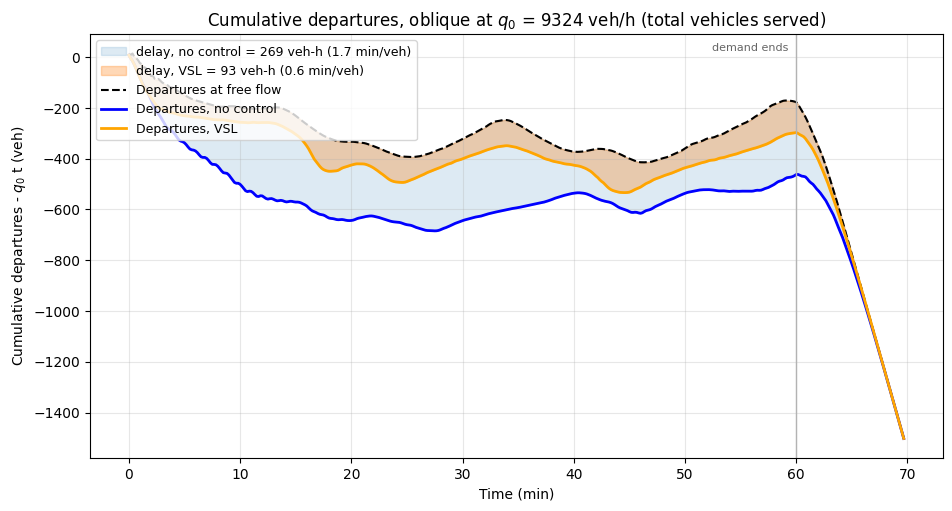

In [32]:
# Oblique (reduced) cumulative curves: subtract a background rate from every curve so the
# delay regions are readable instead of a sliver against ~9300 vehicles. Q0 is cosmetic --
# it tilts the axes without changing any area (Cassidy & Bertini 1999).
Q0 = arrivals[-1] #arrivals[-1] / t_grid[-1]            # veh/h, the run's own average rate
oblique = lambda curve: curve - Q0 * t_grid

delay_nc = np.trapz(ff_departures - nc_departures, dx=time_step)
delay_ctl = np.trapz(ff_departures - ctl_departures, dx=time_step)
n_veh = arrivals[-1]

plt.figure(figsize=(11, 5.5))
plt.fill_between(t_grid_min, oblique(ff_departures), oblique(nc_departures), color="tab:blue", alpha=0.15,
                 label=f"delay, no control = {delay_nc:.0f} veh-h ({60 * delay_nc / n_veh:.1f} min/veh)")
plt.fill_between(t_grid_min, oblique(ff_departures), oblique(ctl_departures), color="tab:orange", alpha=0.3,
                 label=f"delay, VSL = {delay_ctl:.0f} veh-h ({60 * delay_ctl / n_veh:.1f} min/veh)")
plt.plot(t_grid_min, oblique(ff_departures), color="k", ls="--", label="Departures at free flow")
plt.plot(t_grid_min, oblique(nc_departures), color="blue", lw=2, label="Departures, no control")
plt.plot(t_grid_min, oblique(ctl_departures), color="orange", lw=2, label="Departures, VSL")
plt.axvline(day["data_inflow"].shape[0] * time_step * 60, color="0.7", lw=1)
plt.annotate("demand ends", (day["data_inflow"].shape[0] * time_step * 60, plt.ylim()[1]),
             xytext=(-6, -12), textcoords="offset points", ha="right", fontsize=8, color="0.4")
plt.title(rf"Cumulative departures, oblique at $q_0$ = {Q0:.0f} veh/h (total vehicles served)")
plt.xlabel("Time (min)"); plt.ylabel(r'Cumulative departures - $q_0$ t (veh)')
plt.legend(loc="upper left", fontsize=9); plt.grid(alpha=0.3)
plt.show()

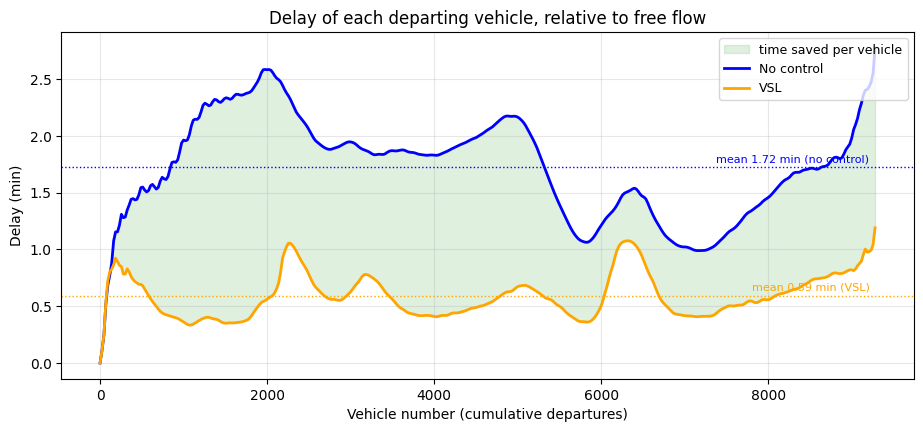

worst vehicle: no control 2.77 min, VSL 1.19 min
mean over vehicles: 1.72 / 0.59 min (from total delay: 1.73 / 0.60 min)


In [11]:
# Per-vehicle delay: the HORIZONTAL gap between a departure curve and the free-flow one.
# Vehicle n departs at t_run(n) but would have departed at t_ff(n), so it lost the
# difference. Averaging over vehicles returns total delay / vehicles served.
def departure_times(curve):
    """Time each cumulative departure count is first reached.

    Only the strictly increasing part of the curve is used: once a run has drained its
    curve is flat, and a flat stretch has no well-defined departure time.
    """
    rising = np.r_[True, np.diff(curve) > 0]
    return np.interp(veh_index, curve[rising], t_grid[rising])

# The last handful of vehicles are dropped: all three curves flatten as the corridor
# empties, so the horizontal gap there is numerically meaningless.
veh_index = np.linspace(0, 0.995 * arrivals[-1], 400)
t_ff = departure_times(ff_departures)
delay_per_veh_nc = (departure_times(nc_departures) - t_ff) * 60      # minutes
delay_per_veh_ctl = (departure_times(ctl_departures) - t_ff) * 60

plt.figure(figsize=(11, 4.5))
plt.fill_between(veh_index, delay_per_veh_ctl, delay_per_veh_nc, color="tab:green", alpha=0.15,
                 label="time saved per vehicle")
plt.plot(veh_index, delay_per_veh_nc, color="blue", lw=2, label="No control")
plt.plot(veh_index, delay_per_veh_ctl, color="orange", lw=2, label="VSL")
for series, color, name in [(delay_per_veh_nc, "blue", "no control"), (delay_per_veh_ctl, "orange", "VSL")]:
    plt.axhline(series.mean(), color=color, ls=":", lw=1)
    plt.annotate(f"mean {series.mean():.2f} min ({name})", (veh_index[-1], series.mean()),
                 xytext=(-4, 4), textcoords="offset points", ha="right", fontsize=8, color=color)
plt.title("Delay of each departing vehicle, relative to free flow")
plt.xlabel("Vehicle number (cumulative departures)"); plt.ylabel("Delay (min)")
plt.legend(loc="upper right", fontsize=9); plt.grid(alpha=0.3)
plt.show()

print(f"worst vehicle: no control {delay_per_veh_nc.max():.2f} min, VSL {delay_per_veh_ctl.max():.2f} min")
print(f"mean over vehicles: {delay_per_veh_nc.mean():.2f} / {delay_per_veh_ctl.mean():.2f} min "
      f"(from total delay: {60 * delay_nc / n_veh:.2f} / {60 * delay_ctl / n_veh:.2f} min)")

In [12]:
# Same comparison over the 60 min window only, i.e. without draining. The two runs then
# serve different vehicle-km, so the free-flow baseline is taken from the uncontrolled run.
ff_window = ff_tts_vkm(nc["rho"], nc["v"], lanes, time_step, L, P["v_free"])
for name, run in [("no control", nc), ("VSL", ctl)]:
    veh_km = (run["rho"] * run["v"] * lanes).sum() * time_step * L
    print(f"{name:11s}: TTS {run['tts']:6.1f}, veh-km {veh_km:7.0f}, delay {run['tts'] - ff_window:6.1f} veh-h")
d_w, do_w = nc["tts"] - ff_window, ctl["tts"] - ff_window
print(f"  60 min window: free-flow TTS {ff_window:.1f} veh-h, CC = {100 * (d_w - do_w) / d_w:.1f}%")

no control : TTS  550.6, veh-km   22991, delay  265.7 veh-h
VSL        : TTS  383.5, veh-km   23537, delay   98.6 veh-h
  60 min window: free-flow TTS 284.9 veh-h, CC = 62.9%


In [13]:
# Area between the two departure curves: the time saved, in veh-hours (not a vehicle count).
area_saved = np.trapz(ctl_departures - nc_departures, dx=time_step)
print(f"TTS saved by VSL control: {area_saved:.1f} veh-h  "
      f"(TTS difference of the drained runs: {nc_ff['tts'] - ctl_ff['tts']:.1f} veh-h)")

TTS saved by VSL control: 176.1 veh-h  (TTS difference of the drained runs: 176.1 veh-h)


In [14]:
def total_exits(run):
    q = run["rho"] * run["v"] * lanes          # per-segment outflow, veh/h
    return q[:, -1] + (q * P["beta"] / (1 - P["beta"])).sum(axis=1)

nc_cum = np.cumsum(total_exits(nc)) * time_step
ctl_cum = np.cumsum(total_exits(ctl)) * time_step
area_saved = np.trapz(ctl_cum - nc_cum, dx=time_step)
print(f"TTS saved from cumulative curves: {area_saved:.1f} veh-h")   # 166.9

TTS saved from cumulative curves: 166.9 veh-h


(361,)


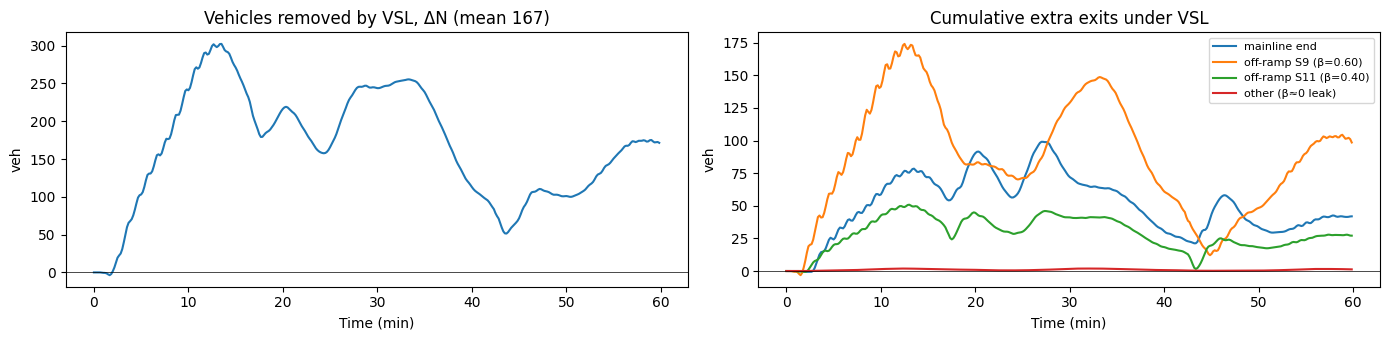

In [15]:
def exits(run):
    q = run["rho"] * run["v"] * lanes                       # segment outflow, veh/h
    off = q * P["beta"] / (1 - P["beta"])
    return q[:, -1], off

print(nc["N"].shape)

dN = nc["N"][:-1] - ctl["N"][:-1]
main_nc, off_nc = exits(nc)
main_ctl, off_ctl = exits(ctl)
cum = lambda x: np.cumsum(x, axis=0) * time_step
d_main = cum(main_ctl - main_nc)
d_off = cum(off_ctl - off_nc)                               # (t, n_seg)
big_off = np.nonzero(P["beta"] > 0.01)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 3.5))
ax1.plot(T_min, dN); ax1.axhline(0, color="k", lw=0.5)
ax1.set(title=f"Vehicles removed by VSL, ΔN (mean {dN.mean():.0f})", xlabel="Time (min)", ylabel="veh")
ax2.plot(T_min, d_main, label="mainline end")
for i in big_off:
    ax2.plot(T_min, d_off[:, i], label=f"off-ramp S{i} (β={P['beta'][i]:.2f})")
ax2.plot(T_min, d_off.sum(1) - d_off[:, big_off].sum(1), label="other (β≈0 leak)")
ax2.axhline(0, color="k", lw=0.5)
ax2.set(title="Cumulative extra exits under VSL", xlabel="Time (min)", ylabel="veh"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Actuator ablation.** *Only i*: apply the optimal limit at segment i alone. *Without i*: apply it everywhere except segment i. If the gain is spread across actuators, only-i values roughly add up to the total. If they don't, the gain depends on coordinated actions across several segments.

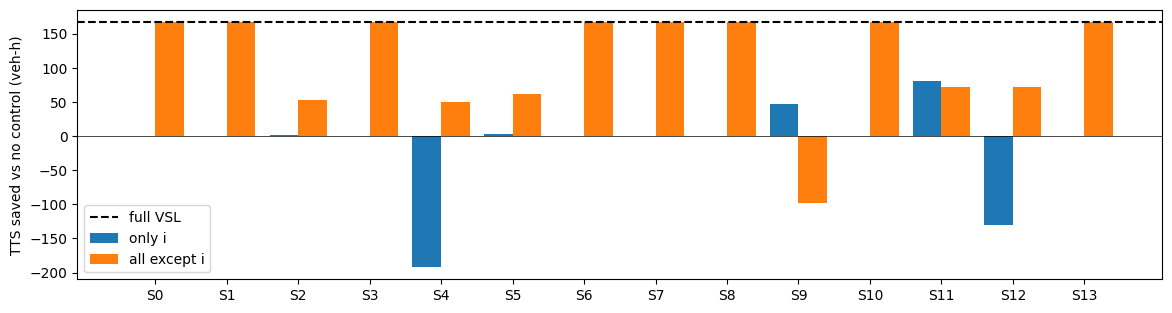

In [16]:
only_i, without_i = np.zeros(n_seg), np.zeros(n_seg)
for i in range(n_seg):
    m = np.full_like(vsl, NO_LIMIT); m[:, i] = vsl[:, i]
    only_i[i] = nc["tts"] - simulate(m)["tts"]
    m = vsl.copy(); m[:, i] = NO_LIMIT
    without_i[i] = nc["tts"] - simulate(m)["tts"]

x = np.arange(n_seg)
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(x - 0.2, only_i, 0.4, label="only i")
ax.bar(x + 0.2, without_i, 0.4, label="all except i")
ax.axhline(nc["tts"] - ctl["tts"], color="k", ls="--", label="full VSL")
ax.axhline(0, color="k", lw=0.5)
ax.set_xticks(x); ax.set_xticklabels([f"S{i}" for i in x])
ax.set(ylabel="TTS saved vs no control (veh-h)"); ax.legend()
plt.show()

## Per-segment summary

In [17]:
def at_bound(name, key):
    lo, hi = CALIB_PARAM_BOUNDS[name]
    tol = 0.01 * (hi - lo)
    return np.where(np.abs(P[key] - lo) < tol, f"{name}=lo", np.where(np.abs(P[key] - hi) < tol, f"{name}=hi", ""))

bounds = [at_bound("v_free", "v_free"), at_bound("rho_crit", "p_crit"), at_bound("a", "a")]

summary = pd.DataFrame({
    "beta": P["beta"], "r (veh/h)": P["r"],
    "Q_cap": Q_cap[1:-1], "max obs q": q_agg[:, 1:-1].max(axis=0),
    "FD params at bound": [", ".join(s for s in col if s) for col in zip(*bounds)],
    "drop (ff vs congested)": drop[1:-1],
    "ΔTTS in segment": time_step * ((nc["rho"] - ctl["rho"]) * lanes * L).sum(axis=0),
    "VSL binding (frac)": binding.mean(axis=0),
    "off-FD, no ctrl": off_fd,
    "only-i saving": only_i, "without-i saving": without_i,
}, index=[f"S{i}" for i in range(n_seg)]).round(2)
summary

,beta,r (veh/h),Q_cap,max obs q,FD params at bound,drop (ff vs congested),ΔTTS in segment,VSL binding (frac),"off-FD, no ctrl",only-i saving,without-i saving
S0,0.0,0.0,1941.04,1434.00,a=hi,0.38,22.56,0.00,0.16,0.00,167.12
S1,0.0,2000.0,1771.67,1667.69,a=hi,0.38,21.95,0.00,0.40,0.00,167.12
S2,0.0,0.0,1409.08,1624.34,a=hi,0.31,15.24,0.07,0.52,2.07,52.90
S3,0.0,0.0,142.10,1539.32,"v_free=lo, rho_crit=lo, a=lo",0.29,13.51,0.00,0.99,0.00,167.12
S4,0.0,0.0,1478.80,1284.26,a=hi,0.37,14.33,0.06,0.19,-191.90,50.38
S5,0.0,0.0,1121.70,1138.40,"v_free=lo, a=hi",0.35,13.86,0.01,0.41,3.16,60.96
S6,0.0,0.0,1342.38,1166.48,a=hi,0.38,13.57,0.00,0.17,0.00,167.12
S7,0.0,0.0,1140.11,1222.21,"v_free=lo, a=hi",0.29,12.44,0.00,0.16,0.00,167.12
S8,0.0,0.0,142.10,1314.95,"v_free=lo, rho_crit=lo, a=lo",0.33,10.45,0.00,0.95,0.00,167.12
S9,0.6,0.0,1246.28,1451.50,,0.34,7.25,0.02,0.00,47.64,-98.76


In [18]:
print(f"TTS saved: {nc['tts'] - ctl['tts']:.1f} veh-h; sum of only-i savings: {only_i.sum():.1f} veh-h")
print(f"Extra exits by t=60: mainline {d_main[-1]:.0f}, " +
      ", ".join(f"off-ramp S{i} {d_off[-1, i]:.0f}" for i in big_off) + f"; ΔN(end) = {dN[-1]:.0f}")
print(f"Segments where observed flow > 1.2 x Q_cap (static FD not credible): "
      f"{', '.join(summary.index[summary['max obs q'] > 1.2 * summary['Q_cap']])}")
print(f"Actuators that matter (removing costs > 10% of the gain): "
      f"{', '.join(summary.index[(nc['tts'] - ctl['tts']) - without_i > 0.1 * (nc['tts'] - ctl['tts'])])}")

TTS saved: 167.1 veh-h; sum of only-i savings: -188.8 veh-h
Extra exits by t=60: mainline 42, off-ramp S9 99, off-ramp S11 27; ΔN(end) = 171
Segments where observed flow > 1.2 x Q_cap (static FD not credible): S3, S8, S10, S11, S13
Actuators that matter (removing costs > 10% of the gain): S2, S4, S5, S9, S11, S12
